In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Load the dataset
df = pd.read_csv("/content/insurance.csv")

In [ ]:
df.sample(10)

,age,sex,bmi,children,smoker,region,charges
232,19,female,17.800,0,no,southwest,1727.78500
492,18,female,25.080,0,no,northeast,2196.47320
686,42,male,26.125,2,no,northeast,7729.64575
808,18,male,30.140,0,no,southeast,1131.50660
1086,55,male,28.975,0,no,northeast,10796.35025
887,36,female,30.020,0,no,northwest,5272.17580
470,27,male,32.670,0,no,southeast,2497.03830
624,59,male,28.785,0,no,northwest,12129.61415
943,19,male,22.610,0,no,northwest,1628.47090
908,63,male,39.800,3,no,southwest,15170.06900


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [ ]:
# Shape
print("Shape of Dataset:")
print(df.shape)

# Columns
print("\nColumns:")
print(df.columns)

# Dataset Information
print("\nDataset Information:")
df.info()

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate Rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Summary Statistics
print("\nSummary Statistics:")
display(df.describe().T)

Shape of Dataset:
(1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows:
1

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


### Observation

- Dataset contains 1338 records and 7 variables.
- No missing values were found.
- One duplicate row exists.
- BMI may contain outliers.
- The target variable (charges) appears to be positively skewed based on the difference between mean and median.

### Observation

- The age variable is fairly distributed across different age groups.
- No significant skewness is observed.
- No outliers are present in the age column.
- The feature appears clean and can be used directly for model building.

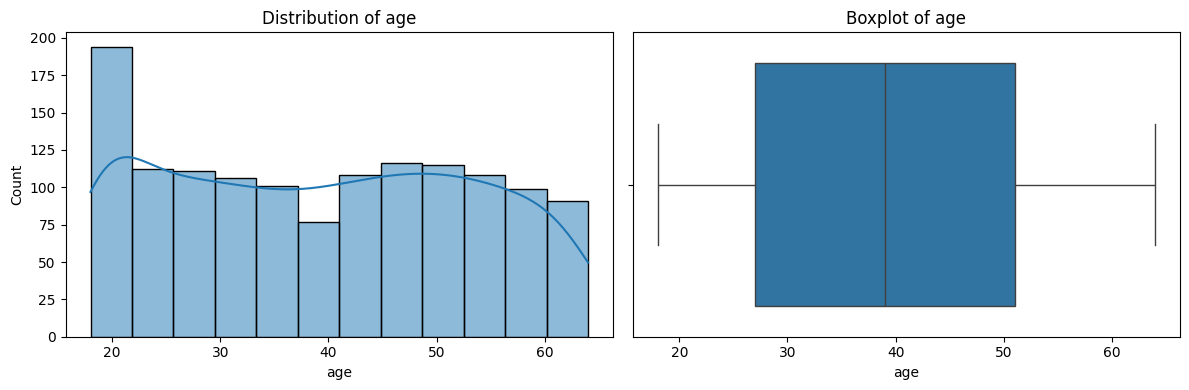

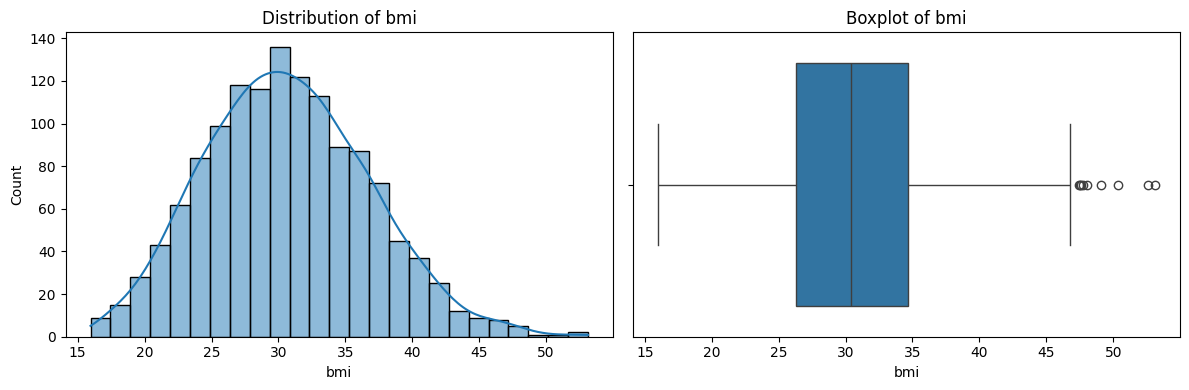

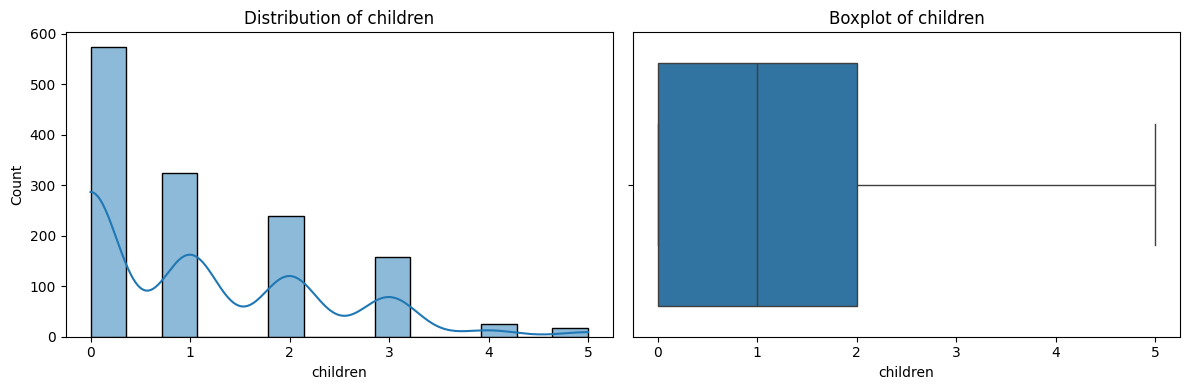

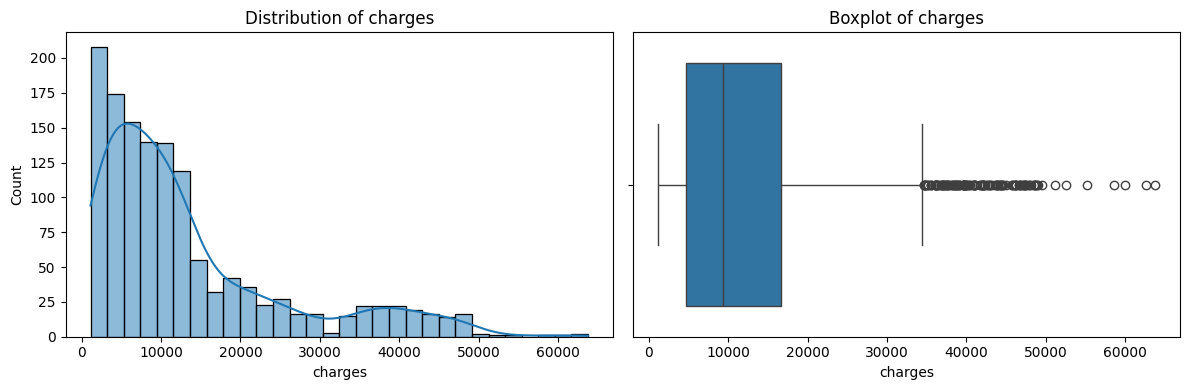

In [ ]:
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12,4))

    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f'Distribution of {col}')

    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

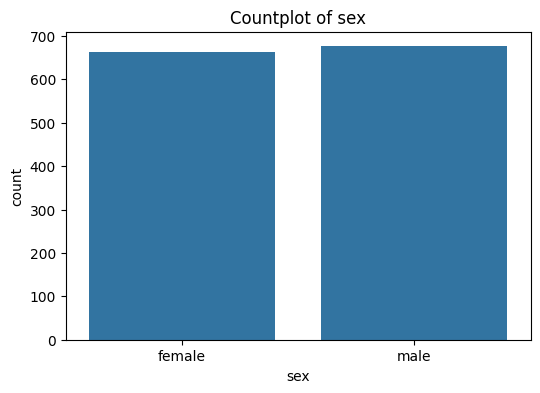

sex
male      676
female    662
Name: count, dtype: int64

Percentage
sex
male      50.52
female    49.48
Name: proportion, dtype: float64


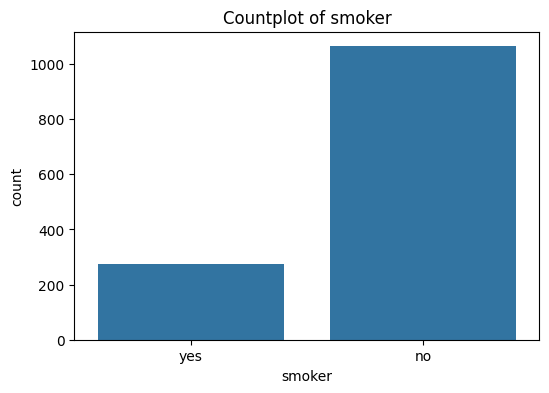

smoker
no     1064
yes     274
Name: count, dtype: int64

Percentage
smoker
no     79.52
yes    20.48
Name: proportion, dtype: float64


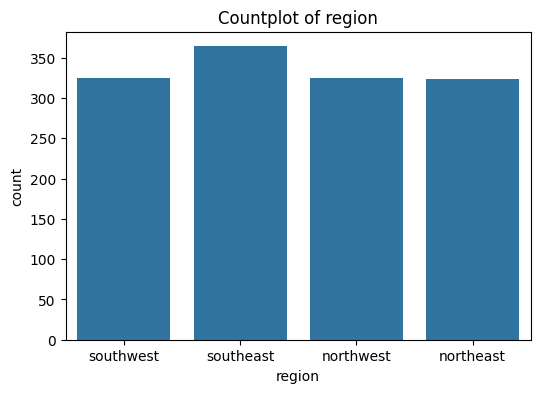

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Percentage
region
southeast    27.20
southwest    24.29
northwest    24.29
northeast    24.22
Name: proportion, dtype: float64


In [ ]:
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(data=df, x=col)

    plt.title(f"Countplot of {col}")

    plt.show()

    # Count
    print(df[col].value_counts())

    # Percentage
    print("\nPercentage")
    print(round(df[col].value_counts(normalize=True)*100,2))

    print("="*50)

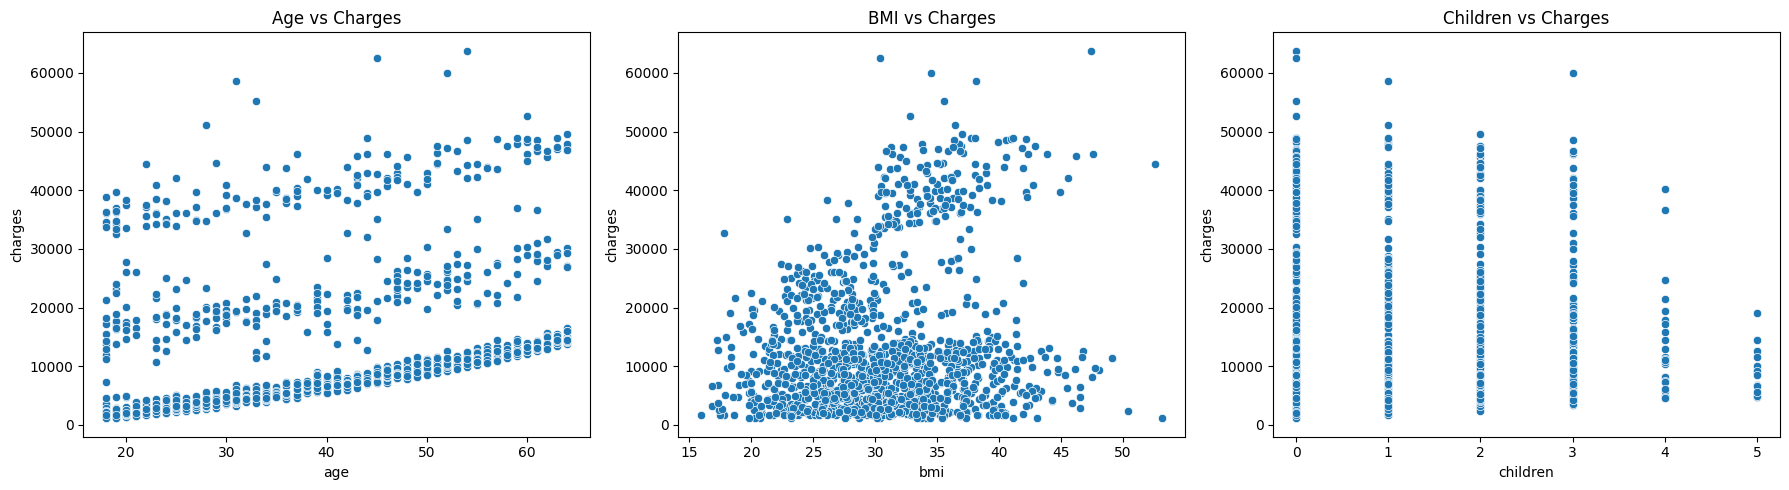

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=df, x='age', y='charges', ax=axes[0])
axes[0].set_title("Age vs Charges")

sns.scatterplot(data=df, x='bmi', y='charges', ax=axes[1])
axes[1].set_title("BMI vs Charges")

sns.scatterplot(data=df, x='children', y='charges', ax=axes[2])
axes[2].set_title("Children vs Charges")

plt.tight_layout()
plt.show()

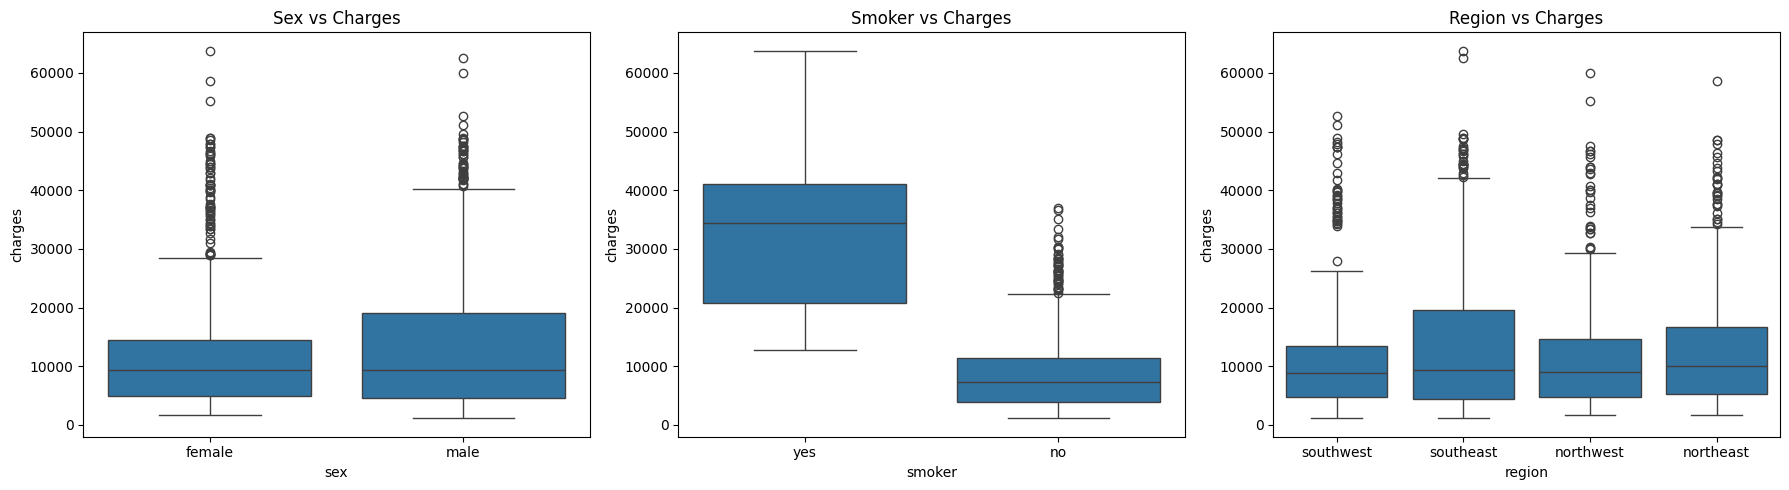

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(data=df, x='sex', y='charges', ax=axes[0])
axes[0].set_title("Sex vs Charges")

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1])
axes[1].set_title("Smoker vs Charges")

sns.boxplot(data=df, x='region', y='charges', ax=axes[2])
axes[2].set_title("Region vs Charges")

plt.tight_layout()
plt.show()

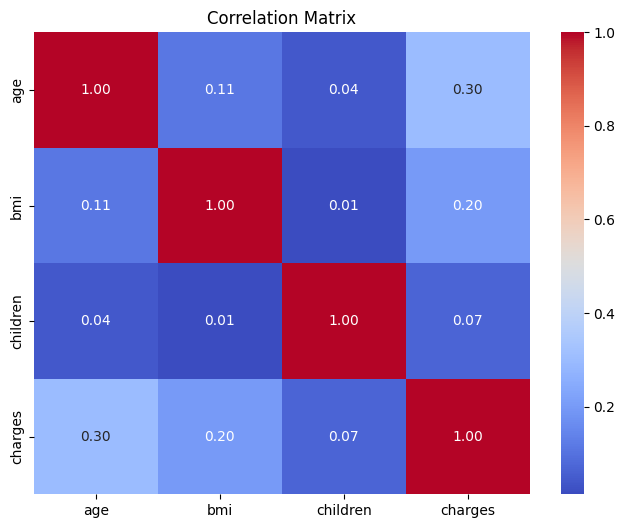

In [ ]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

In [ ]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (1338, 7)
After: (1337, 7)


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 9 outliers
children: 0 outliers
charges: 139 outliers


### Outlier Analysis

- No outliers were found in the `age` and `children` variables.
- The `bmi` variable contains 9 outliers, but these represent realistic BMI values and were retained.
- The `charges` variable contains 139 outliers. Since these correspond to genuine high medical expenses rather than data errors, they were not removed.
- Therefore, no outlier treatment was applied.

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True,
    dtype=int
)


In [ ]:
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   charges           1337 non-null   float64
 4   sex_male          1337 non-null   int64  
 5   smoker_yes        1337 non-null   int64  
 6   region_northwest  1337 non-null   int64  
 7   region_southeast  1337 non-null   int64  
 8   region_southwest  1337 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 104.5 KB


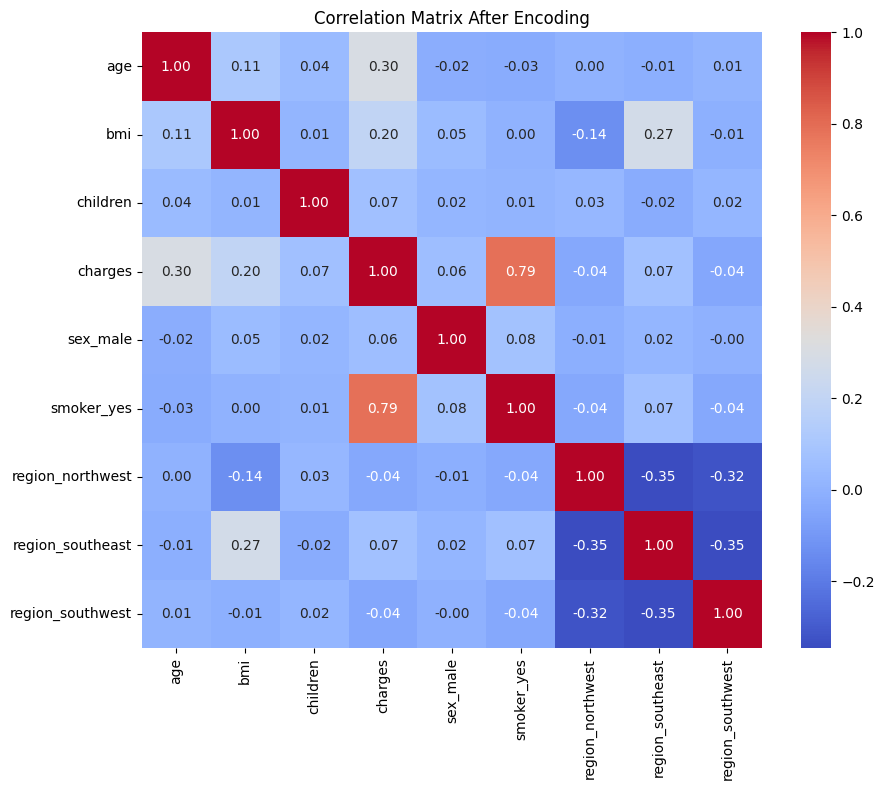

In [ ]:
plt.figure(figsize=(10,8))

corr = df_encoded.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix After Encoding")

plt.show()

In [ ]:
import statsmodels.api as sm

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_sm = sm.add_constant(X)

model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Fri, 26 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:58:18   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

In [ ]:
X.describe()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,0.504862,0.204936,0.242334,0.272251,0.243082
std,14.044333,6.100468,1.205571,0.500163,0.403806,0.428655,0.445285,0.429104
min,18.000000,15.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,26.290000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,30.400000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,51.000000,34.700000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,64.000000,53.130000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,age,7.696862
1,bmi,11.359739
2,children,1.810971
3,sex_male,2.001959
4,smoker_yes,1.261476
5,region_northwest,1.888020
6,region_southeast,2.265574
7,region_southwest,1.960750


all features

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(cv_scores)
print(cv_scores.mean())

[0.69409981 0.76357239 0.72107631 0.70579211 0.74424615]
0.7257573536108111


In [ ]:
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

4177.045561036319
35478020.67523561
5956.342894363588
0.8069287081198011


In [ ]:
n=X_test.shape[0]
p=X_test.shape[1]

adj_r2=1-((1-r2)*(n-1)/(n-p-1))

print(adj_r2)

0.8009651160926134


In [ ]:
print("Train R2 :",lr.score(X_train,y_train))
print("Test R2 :",lr.score(X_test,y_test))

Train R2 : 0.7299057809339075
Test R2 : 0.8069287081198011


In [ ]:
residuals = y_test - y_pred

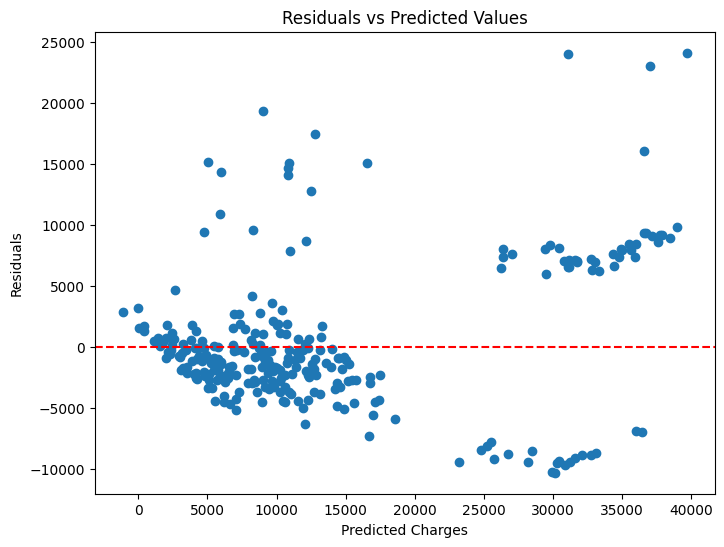

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

<Figure size 600x600 with 0 Axes>

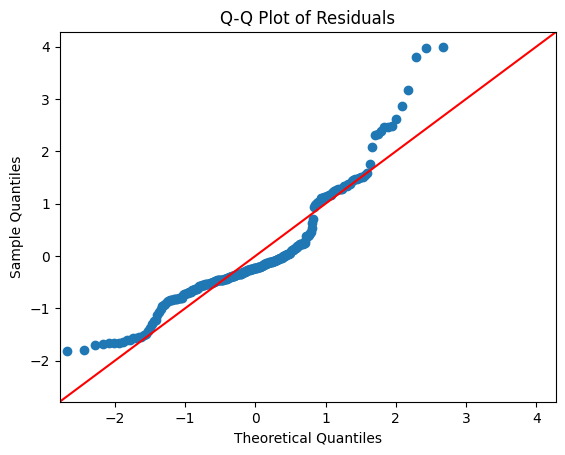

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

sm.qqplot(residuals, line='45', fit=True)

plt.title("Q-Q Plot of Residuals")

plt.show()

6 feat

In [ ]:
X_selected = df_encoded.drop(
    columns=[
        "charges",
        "sex_male",
        "region_northwest"
    ]
)

y = df_encoded["charges"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr_selected = LinearRegression()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_selected,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(cv_scores)
print("Average CV:", cv_scores.mean())

[0.69436802 0.76391822 0.72257054 0.70588674 0.74441499]
Average CV: 0.726231700535792


In [ ]:
lr_selected.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr_selected.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² :", r2)


MAE : 4175.84335718232
MSE : 35491394.044489466
RMSE: 5957.465404388805
R² : 0.8068559302807479


In [ ]:
n = X_test.shape[0]   # Number of observations
p = X_test.shape[1]   # Number of predictors

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Adjusted R²:", adj_r2)

Adjusted R²: 0.8024158367239834


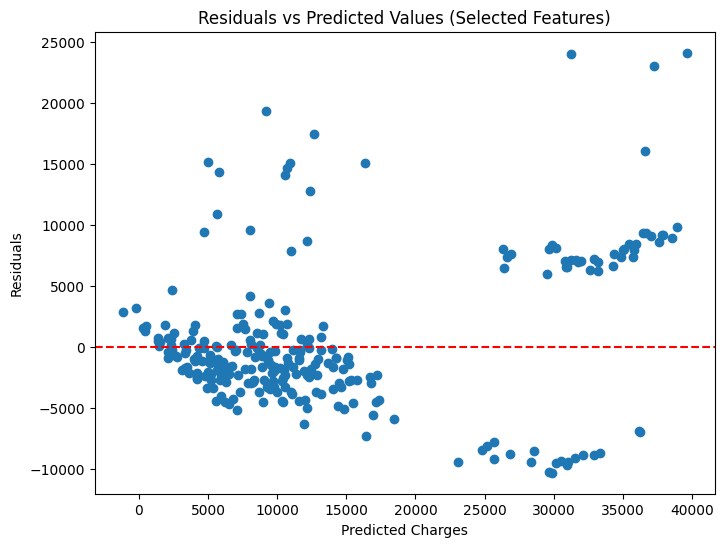

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values (Selected Features)")

plt.show()

In [ ]:
import pandas as pd

# Example new customer
new_customer = pd.DataFrame({
    'age': [35],
    'bmi': [28.5],
    'children': [2],
    'smoker_yes': [1],         # 1 = Smoker, 0 = Non-Smoker
    'region_southeast': [1],   # Southeast
    'region_southwest': [0]    # Southwest
})

# Predict insurance charges
predicted_charge = lr_selected.predict(new_customer)

print(f"Predicted Insurance Charge: ${predicted_charge[0]:.2f}")

Predicted Insurance Charge: $29934.80


In [ ]:
new_customer = pd.DataFrame({
    'age': [25],
    'bmi': [22.3],
    'children': [0],
    'smoker_yes': [0],
    'region_southeast': [0],
    'region_southwest': [1]
})

predicted_charge = lr_selected.predict(new_customer)

print(f"Predicted Insurance Charge: ${predicted_charge[0]:.2f}")

Predicted Insurance Charge: $1517.47


In [ ]:
import pandas as pd

print("Enter Customer Details")

age = int(input("Age: "))
bmi = float(input("BMI: "))
children = int(input("Children: "))
smoker = int(input("Smoker (1=Yes, 0=No): "))

print("\nRegion")
print("1 = Northeast")
print("2 = Southeast")
print("3 = Southwest")

region = int(input("Choose Region: "))

# One-Hot Encoding
region_southeast = 1 if region == 2 else 0
region_southwest = 1 if region == 3 else 0

new_customer = pd.DataFrame({
    "age": [age],
    "bmi": [bmi],
    "children": [children],
    "smoker_yes": [smoker],
    "region_southeast": [region_southeast],
    "region_southwest": [region_southwest]
})

prediction = lr_selected.predict(new_customer)

print(f"\nEstimated Medical Insurance Charge: ${prediction[0]:.2f}")\

Enter Customer Details
Age: 50
BMI: 25
Children: 1
Smoker (1=Yes, 0=No): 1

Region
1 = Northeast
2 = Southeast
3 = Southwest
Choose Region: 2

Estimated Medical Insurance Charge: $32018.35
